In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

vectorizer = TfidfVectorizer()

df = pd.read_csv('../data/quran.csv')
cols = list(df.columns)
cols[0] = 'chapter#' 
cols[1] = 'verse#'
cols[2] = 'd_verse'
cols[3] = 'verse'
cols[9] = 'd_chapter'
cols[10] = 'chapter'
df.columns = cols

df = df.sort_values(by=['chapter#','verse#']).reset_index(drop=True)
df.drop([6459], axis=0, inplace=True)


In [3]:
for idx, x in df['verse'].items():
    if pd.isna(x): print(idx)

In [4]:
df[pd.isna(df.verse)]
df.tail()

,chapter#,verse#,d_verse,verse,22b81fd12c136d4cf67a37de941908d83eaf8e97571c4983f9308d30d52ad8f9,0.25,1.1,١,1.2,d_chapter,chapter,1.3,0.1
6454,114,2,مَلِكِ ٱلنَّاسِ,ملك الناس,ee43221a2d70da314a28481e2858b355b84ea76cc5505a...,60.0,604,٦٠٤,6456,سُورَةُ النَّاسِ,سورة الناس,30,0
6455,114,3,إِلَٰهِ ٱلنَّاسِ,الٰه الناس,83ea524a3332531b96d8b06c387410ac2371c0e79d7960...,60.0,604,٦٠٤,6457,سُورَةُ النَّاسِ,سورة الناس,30,0
6456,114,4,مِن شَرِّ ٱلۡوَسۡوَاسِ ٱلۡخَنَّاسِ,من شر الوسواس الخناس,04af28c8924483450a6968f46189467994eccf451daa8a...,60.0,604,٦٠٤,6458,سُورَةُ النَّاسِ,سورة الناس,30,0
6457,114,5,ٱلَّذِي يُوَسۡوِسُ فِي صُدُورِ ٱلنَّاسِ,الذي يوسوس في صدور الناس,6d5da11704c8c0a3fce24b7038f963c0ff6922063d7673...,60.0,604,٦٠٤,6459,سُورَةُ النَّاسِ,سورة الناس,30,0
6458,114,6,مِنَ ٱلۡجِنَّةِ وَٱلنَّاسِ,من الجنة والناس,3020b3a83101b27789ad8db9a84b00a9c97271013bf79e...,60.0,604,٦٠٤,6460,سُورَةُ النَّاسِ,سورة الناس,30,0


In [5]:
vectorized_ayaah = vectorizer.fit_transform(df['verse'])

kmeans = KMeans(n_clusters=70, random_state=42)
df['cluster'] = kmeans.fit_predict(vectorized_ayaah)
print(df)

      chapter#  verse#  ... 0.1 cluster
0            1       1  ...   0      10
1            1       2  ...   0      16
2            1       3  ...   0      10
3            1       4  ...   0      56
4            1       5  ...   0       0
...        ...     ...  ...  ..     ...
6454       114       2  ...   0       0
6455       114       3  ...   0      17
6456       114       4  ...   0      59
6457       114       5  ...   0       8
6458       114       6  ...   0      59

[6459 rows x 14 columns]


In [6]:
from sklearn.preprocessing import normalize

vectorized_ayaah_norm = normalize(vectorized_ayaah)

kmeans = KMeans(n_clusters=70, random_state=42)
df['cluster'] = kmeans.fit_predict(vectorized_ayaah_norm)

In [7]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Don't wrap to fit width
pd.set_option('display.max_colwidth', None)  # Show full column content

df.head(100)

,chapter#,verse#,d_verse,verse,22b81fd12c136d4cf67a37de941908d83eaf8e97571c4983f9308d30d52ad8f9,0.25,1.1,١,1.2,d_chapter,chapter,1.3,0.1,cluster
0,1,1,بِسۡمِ ٱللَّهِ ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,بسم الله الرحمٰن الرحيم,803dee27b5a9ddf866112eac2f8a34e5bd83ca08015ec4acaaffeba25a378352,0.25,1,١,2,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,10
1,1,2,ٱلۡحَمۡدُ لِلَّهِ رَبِّ ٱلۡعَٰلَمِينَ,الحمد لله رب العٰلمين,ef2e84a7a99f9340845888a735cf6950853f9e1a13cff30f4c1e7648e56ee51b,0.25,1,١,3,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,16
2,1,3,ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,الرحمٰن الرحيم,fa43107ca02d890e5115053aed9835bfbefb79ffa6846491cf7dfc67c8fd8be7,0.25,1,١,4,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,10
3,1,4,مَٰلِكِ يَوۡمِ ٱلدِّينِ,مٰلك يوم الدين,4355fb3e57b0b8b4e47545d28d30b98359fea1a18e5bfc3dc948eeab653901e5,0.25,1,١,5,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,56
4,1,5,إِيَّاكَ نَعۡبُدُ وَإِيَّاكَ نَسۡتَعِينُ,اياك نعبد واياك نستعين,8fc4ad4ff4e86be9abf8b5c66fd47a316b760844456c87ec85806ac3473471e9,0.25,1,١,6,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,0
5,1,6,ٱهۡدِنَا ٱلصِّرَٰطَ ٱلۡمُسۡتَقِيمَ,اهدنا الصرٰط المستقيم,3588b00e5f634a98aad43530808b52caa9b481dad46ddaad45eac81e32ea93c4,0.25,1,١,7,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,0
6,1,7,صِرَٰطَ ٱلَّذِينَ أَنۡعَمۡتَ عَلَيۡهِمۡ غَيۡرِ ٱلۡمَغۡضُوبِ عَلَيۡهِمۡ وَلَا ٱلضَّآلِّينَ,صرٰط الذين انعمت عليهم غير المغضوب عليهم ولا الضالين,2a2c9b6be73c32c7956511168c280f11d1d7c45d8775749a630dd7ecf09213b4,0.25,1,١,8,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,44
7,2,0,سُورَةُ البَقَرَةِ,سورة البقرة,b9646eafdec422426ae5fbe958306ee6b0a4471328a4f6289e8599484fed4b70,0.25,2,٢,9,سُورَةُ البَقَرَةِ,سورة البقرة,1,0,6
8,2,0,بِسۡمِ ٱللَّهِ ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,بسم الله الرحمٰن الرحيم,803dee27b5a9ddf866112eac2f8a34e5bd83ca08015ec4acaaffeba25a378352,0.25,2,٢,10,سُورَةُ البَقَرَةِ,سورة البقرة,1,0,10
9,2,1,الٓمٓ,الم,49c5355bd921dc0d810e3be457432004847a72d5dbe754562be895be707be6c3,0.25,2,٢,11,سُورَةُ البَقَرَةِ,سورة البقرة,1,0,55


In [56]:
mut_dict = {"cluster":[], "verse":[]}
unique_groups = df['cluster'].unique()
for x in unique_groups:
    temp_verse_list = []
    temp_df=df[df.cluster == x]
    for y in temp_df['verse']:
        temp_verse_list.append(y)

    mut_dict['cluster'].append(x)
    mut_dict['verse'].append(temp_verse_list)

mut_df = pd.DataFrame(mut_dict)
mut_df.head(30)
    


cluster  \
0        10   
1        16   
2        56   
3         0   
4        44   
5         6   
6        55   
7        21   
8        48   
9        68   
10       63   
11       60   
12       43   
13       29   
14       27   
15       54   
16       46   
17        8   
18       59   
19       19   
20       50   
21       14   
22        1   
23        7   
24        2   
25       41   
26       35   
27       69   
28        5   
29       12   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [57]:
import pprint
new_mut_dict = df.groupby('cluster')['verse'].apply(list).to_dict()
pprint.pprint(new_mut_dict, width=100, depth=2)


{0: ['اياك نعبد واياك نستعين',
     'اهدنا الصرٰط المستقيم',
     'فازلهما الشيطٰن عنها فاخرجهما مما كانا فيه وقلنا اهبطوا بعضكم لبعض عدو ولكم في الارض مستقر '
     'ومتٰع الىٰ حين',
     'يٰبني اسرٰءيل اذكروا نعمتي التي انعمت عليكم واوفوا بعهدي اوف بعهدكم وايٰي فارهبون',
     'واذ ءاتينا موسى الكتٰب والفرقان لعلكم تهتدون',
     'ولقد علمتم الذين اعتدوا منكم في السبت فقلنا لهم كونوا قردة خٰسين',
     'ولقد ءاتينا موسى الكتٰب وقفينا من بعده بالرسل وءاتينا عيسى ابن مريم البينٰت وايدنٰه بروح '
     'القدس افكلما جاءكم رسول بما لا تهوىٰ انفسكم استكبرتم ففريقا كذبتم وفريقا تقتلون',
     'واذ يرفع ابرٰهم القواعد من البيت واسمٰعيل ربنا تقبل منا انك انت السميع العليم',
     'ومن حيث خرجت فول وجهك شطر المسجد الحرام وحيث ما كنتم فولوا وجوهكم شطره لئلا يكون للناس عليكم '
     'حجة الا الذين ظلموا منهم فلا تخشوهم واخشوني ولاتم نعمتي عليكم ولعلكم تهتدون',
     'ولكم في القصاص حيوٰة يٰاولي الالبٰب لعلكم تتقون',
     'نساؤكم حرث لكم فاتوا حرثكم انىٰ شئتم وقدموا لانفسكم واتقوا الله واعلموا انكم ملٰقوه

In [47]:
def elbow_method(data, k_range):
    k_axis = []
    inertias =[]
    for k in range(1, k_range):
        print(f"Testing k={k}...")
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        k_axis.append(k)
        inertias.append(kmeans.inertia_)
    
    fig = plt.subplots(figsize=(10,5))
    plt.plot(k_axis, inertias, 'o-')
    plt.xlabel("Number of clusters")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()

Testing k=1...
Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...
Testing k=11...
Testing k=12...
Testing k=13...
Testing k=14...
Testing k=15...
Testing k=16...
Testing k=17...
Testing k=18...
Testing k=19...
Testing k=20...
Testing k=21...
Testing k=22...
Testing k=23...
Testing k=24...
Testing k=25...
Testing k=26...
Testing k=27...
Testing k=28...
Testing k=29...
Testing k=30...
Testing k=31...
Testing k=32...
Testing k=33...
Testing k=34...
Testing k=35...
Testing k=36...
Testing k=37...
Testing k=38...
Testing k=39...
Testing k=40...
Testing k=41...
Testing k=42...
Testing k=43...
Testing k=44...
Testing k=45...
Testing k=46...
Testing k=47...
Testing k=48...
Testing k=49...
Testing k=50...
Testing k=51...
Testing k=52...
Testing k=53...
Testing k=54...
Testing k=55...
Testing k=56...
Testing k=57...
Testing k=58...
Testing k=59...
Testing k=60...
Testing k=61...
Testing k=62...
Testing k=63...
T

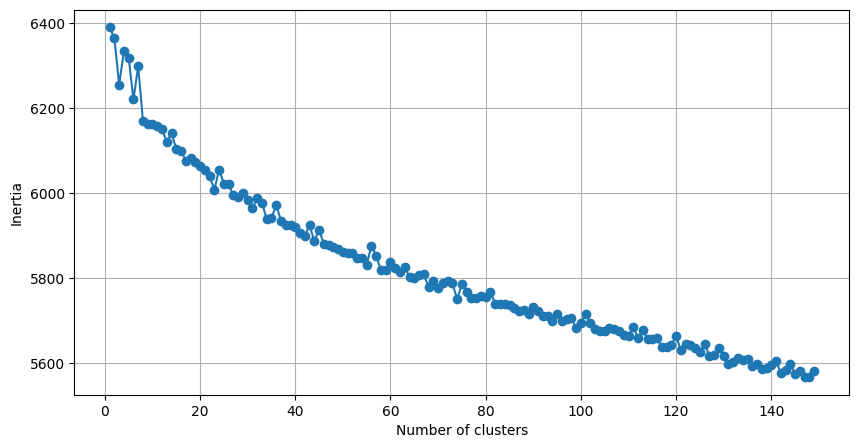

In [53]:
elbow_method(vectorized_ayaah, 150)